Created by Sanish Bhochhibhoya (12/15/2025)

#### Steps:
1) Boundary Creation
2) Utils Creation
3) Creating a domain3D for each
4) merging domain3d
5) Soil and Util types random generation
6) GWT
7) Mean and Std. of properties
8) Spatial

#### To do:
1) SpatialCorrelationMethod2
3) Saving the docs
4) adjustment to different platform like SPECFEM3D, GPRMax

In [1]:
# !pip install pylint

# pyreverse -o png -p ModelGenerator .
# # pyreverse -o png -p MyModule mymodule/

In [2]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [3]:

import pandas as pd
import numpy as np
from geomodgen2d.units_config import Units
import geomodgen2d.main_properties as main_properties
import geomodgen2d.features_config as features_config
import geomodgen2d.random_generators as random_generators
import geomodgen2d.main_property_each as main_property_each

import geomodgen2d.discretized_domain2d as discretized_domain2d
import geomodgen2d.discretized_interfaces2d as discretized_interfaces2d
import geomodgen2d.lithological_domain2d as lithological_domain2d
import geomodgen2d.lithological_domain2d_collection as lithological_domain2d_collection
import geomodgen2d.obstruction2d as obstruction2d
import geomodgen2d.spatial_simulator2d as spatial_simulator2d
import geomodgen2d.generated_model2d_collection as generated_profiles



In [4]:
# Step 1: Unit Configuration

In [5]:
units_config = Units() #Using default units config of "m"

In [6]:
# Step 2: Define Feature and Properties

In [7]:
def add_features_from_pd(main_property_instance, main_property_name, feature_id, pd_dataframe, cov_distribution = None, cov_type='cov'):
    wet_a_colname, wet_b_colname = f"{main_property_name}_wet_a", f"{main_property_name}_wet_b" 
    dry_a_colname, dry_b_colname = f"{main_property_name}_dry_a", f"{main_property_name}_dry_b" 
    for material_name in pd_dataframe.index.tolist():
        # print(material_name)
        wet_a, wet_b = pd_dataframe[wet_a_colname].loc[material_name], pd_dataframe[wet_b_colname].loc[material_name]
        dry_a, dry_b = pd_dataframe[dry_a_colname].loc[material_name], pd_dataframe[dry_b_colname].loc[material_name]

        assert not pd.isna(wet_a), f"wet_a for {material_name} must be a number"
        assert not pd.isna(wet_b), f"wet_a for {material_name} must be a number"
        wet_mean_distribution = random_generators.Uniform(wet_a, wet_b, rng)
        wet_prop = main_property_each.PropertyDistribution(main_property_name, wet_mean_distribution, cov_distribution, stdev_type=cov_type)

        dry_mean_distribution = None
        if pd.isna(dry_a) or pd.isna(dry_b): 
            dry_prop = None
        else:
            dry_mean_distribution = random_generators.Uniform(dry_a, dry_b, rng)
            dry_prop = main_property_each.PropertyDistribution(main_property_name, dry_mean_distribution, cov_distribution, stdev_type=cov_type)
        
        main_property_instance.add_material_property_of_feature(feature_id, material_name, wet_prop, dry_prop)
    return main_property_instance

def add_layer0(main_property_instance, air_val, water_val):
    material_name = 'layer0'
    feature_id = 'def'
    wet_mean_distribution = random_generators.Constant(water_val, rng)
    wet_prop = main_property_each.PropertyDistribution(main_property_name, wet_mean_distribution)

    dry_mean_distribution = random_generators.Constant(air_val, rng)
    dry_prop = main_property_each.PropertyDistribution(main_property_name, dry_mean_distribution)
    main_property_instance.add_material_property_of_feature(feature_id, material_name, wet_prop, dry_prop)
    return main_property_instance
    
has_surface = False
layer0_flag = False #Must be true is has_surface is True. If has_surface False, it can be False.


soil_props_csv = pd.read_csv('data/soil_properties.csv', index_col=0).apply(pd.to_numeric, errors='coerce')
utils_props_csv = pd.read_csv('data/utils_properties.csv', index_col=0).apply(pd.to_numeric, errors='coerce')
rng = np.random.default_rng(seed=42)

soil_materials_distribution = random_generators.DiscreteChoice(x = soil_props_csv.index.tolist(), rng=rng)
utils_materials_distribution = random_generators.DiscreteChoice(x = utils_props_csv.index.tolist(), rng=rng)

feature_config_instance = features_config.FeaturesConfig()
feature_config_instance.add_feature('U', utils_materials_distribution, 'utilities')
feature_config_instance.add_feature('def', soil_materials_distribution, 'soil')

main_properties_config_instance = main_properties.MainPropertiesConfig(feature_config_instance, layer0_flag=layer0_flag)

cov_dc_ec = random_generators.Constant(0.05, rng)
main_properties_info = {'vs': {'desc':'Shear wave velocity in m/s', 'cov': cov_dc_ec, 'layer0':[0, 0]}, 
                       'miu': {'desc':"Poisson's ratio", 'cov': None, 'layer0':[0.5, 0.5]},  
                       'rho': {'desc':"Density", 'cov': cov_dc_ec, 'layer0':[1.2, 1000]}}



for main_property_name, main_props_vals in main_properties_info.items():
    main_property_instance = main_property_each.MainProperty(main_property_name, feature_config_instance, layer0_flag=layer0_flag, description=main_props_vals['desc'])
    main_property_instance = add_features_from_pd(main_property_instance, main_property_name, 'def', pd_dataframe=soil_props_csv, cov_distribution = main_props_vals['cov'], cov_type='cov')
    main_property_instance = add_features_from_pd(main_property_instance, main_property_name, 'U', pd_dataframe=utils_props_csv, cov_distribution = main_props_vals['cov'], cov_type='cov')
    if layer0_flag:
        air_val, water_val = main_props_vals['layer0']
        main_property_instance = add_layer0(main_property_instance, air_val, water_val)
    main_properties_config_instance.add_main_property(main_property_instance)

In [8]:
main_properties_config_instance.print()

Main_Properties: ['vs', 'miu', 'rho']
feature_ids: ['U', 'def']
---------------------------
Property Name: vs
Description: Shear wave velocity in m/s
All Feature IDs: ['U', 'def']
Properties:
{'U': {'Concrete': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F3306F3C90>},
       'Steel': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F3306F3B50>},
       'Rigid PVC': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F3306F3290>},
       'Flexible PVC': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F3306F2ED0>},
       'Masonry': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F3306F3D80>},
       'Wood': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F330700540>}},
 'def': {'Fat Clays': {'both': <geomodgen2d.main_property_each.PropertyDistribution object at 0x000001F3306F36F0>},
         'Lean C

In [9]:
main_properties_config_instance.main_properties['vs'].generate_sample_dict('def', 'Fat Clays')

{'both': {'mean': 172.8747258267156,
  'mean_bm': 0,
  'stdev/cov': 0.05,
  'stdev_type': 'cov'}}

In [10]:
#Auxillary properties definition
x_span = 5
z_span = 3

soil_sett={
    'n_layer_dist':random_generators.DiscreteChoice([1,2], p = [0.5,0.5], rng=rng),
    'gwt_depth': random_generators.Uniform(0, z_span, rng=rng),
    # 'Vs_soils_cov_range':{1200:random_generators.Uniform(0.05, 0.15), 
    #                       760:random_generators.Uniform(0.05, 0.20), 
    #                       460:random_generators.Uniform(0.05, 0.20), 
    #                       0:random_generators.Uniform(0.10, 0.20)},

    'min_vs':30,  #Not adopted yet
    # 'min_vp':60,
}

utilities_sett={
    'n_obs': random_generators.DiscreteChoice([0,1,2], [0.2, 0.5, 0.3], rng=rng),
    'obs_shape': random_generators.DiscreteChoice(['circ2d', 'rect2d',], [1/2, 1/2], rng=rng),
    'dia_obs':random_generators.Uniform(0.2, 1, rng=rng), 
    'lh_obs':random_generators.Uniform(0.2, 1, rng=rng), 
    'obs_x_coord':random_generators.Uniform(0, x_span, rng=rng), 
    'depth_top_dist':random_generators.Discrete2ContinuousPDF([0,3], p = [1,.2], new_del_x = 0.1, rng=rng), #Continuous distribution: discrete to be converted into continuous: also
}

aux_props = main_properties.AuxillaryProperties()
aux_props.add_aux_property('n_layers', soil_sett['n_layer_dist'])
aux_props.add_aux_property('gwt_depth', soil_sett['gwt_depth'])

aux_props.add_aux_property('n_obs', utilities_sett['n_obs'])
aux_props.add_aux_property('obs_shape', utilities_sett['obs_shape'])
aux_props.add_aux_property('dia_obs', utilities_sett['dia_obs'])
aux_props.add_aux_property('lh_obs', utilities_sett['lh_obs'])

aux_props.add_aux_property('obs_x_coord', utilities_sett['obs_x_coord'])
aux_props.add_aux_property('depth_top_utils', utilities_sett['depth_top_dist'])
aux_props.print()

Additional_Properties: dict_keys(['n_layers', 'gwt_depth', 'n_obs', 'obs_shape', 'dia_obs', 'lh_obs', 'obs_x_coord', 'depth_top_utils'])


In [11]:
# Step 2: Model Settings

In [12]:
del_xz_spatial = 0.2    #del_y value for boundary generation and spatial 
del_xz_obs = del_xz_spatial/10    #del_y value for boundary generation and spatial 
del_xz_final = 0.1  #refining del_z for utilities generation
remesh_interp_method = 'linear'
spatial_theta_x = 100
spatial_theta_z = 0.5

interface_sett= {
    'generator_settings':{
                 'max_dz_per_unit_length':1.5,  
                 'generator_option':'uniform',
                },
    'interfaces_depths_generation':'random', 
            'interfaces_depth_reference_point_x':None,
    'surface_factor': 0.5 if has_surface else 0,
    'filter_settings': {
                 'filter_window_length':21, #21 #must be odd
                 'filter_polyorder':7,
                        },
    'processing_settings': {
                'prioritize_lower_interface': True,
            }
    }

In [13]:
# Step 2.1 Domain Creation
domain_spatial = discretized_domain2d.DiscretizedDomain2D(x_span, z_span, del_xz_spatial, del_xz_spatial, units_config)
domain_final   = discretized_domain2d.DiscretizedDomain2D(x_span, z_span, del_xz_final, del_xz_final, units_config)
n_layers=3

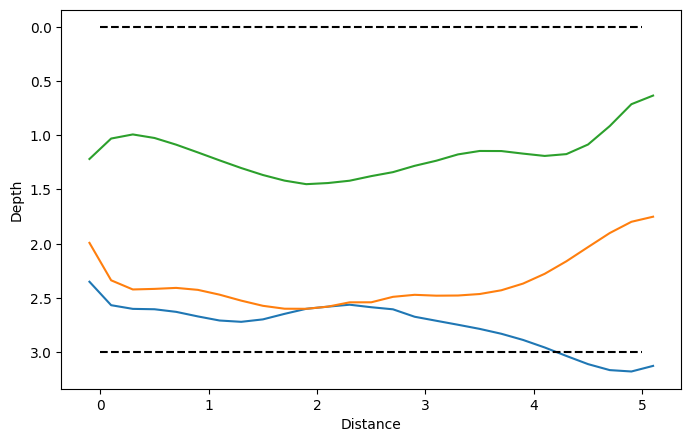

In [14]:
soil_interface, surface_interface = discretized_interfaces2d.generate_interfaces_from_interfaces_settings_dict(domain_spatial, n_layers, interface_sett, remesh_interp_method=remesh_interp_method, rng=rng)
soil_interface.plot()

if has_surface:
    surface_interface.plot()

F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\interfaces_creator2d.py:380: UserWarning: Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.
  warnings.warn("Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.")


'from_interface_config'

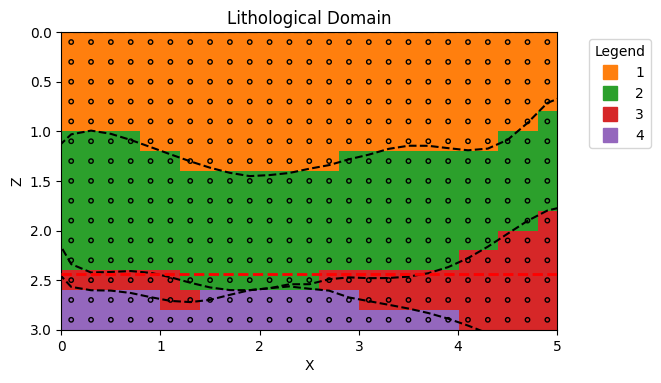

In [15]:
global_soil_interface_config = lithological_domain2d.GlobalSoilInterfaceConfig
global_soil_interface_config.reset()
global_soil_interface_config.set_soil_interface(soil_interface, surface_interface)

gwt_depth = aux_props.aux_properties['gwt_depth'].generate()

name = 'asdf'
lit = lithological_domain2d.LithologicalDomain2D(domain_spatial, gwt_depth, 'soil_lit')
lit.plot(discrete_point_size = 10, plot_interfaces=True)
lit.lm_type

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

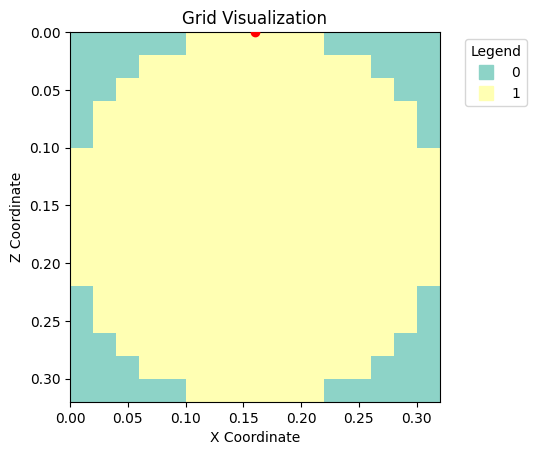

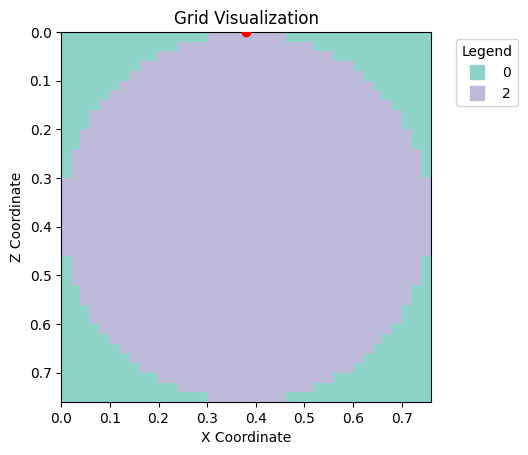

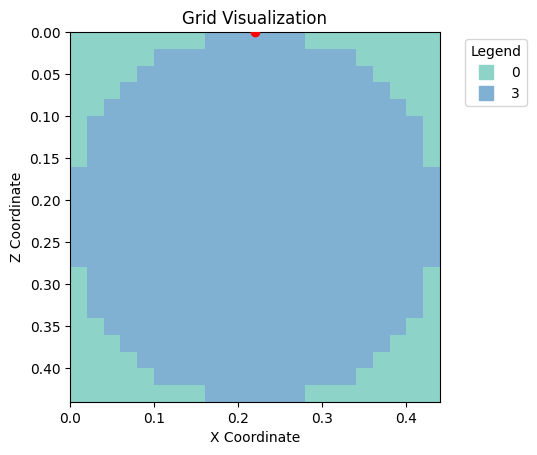

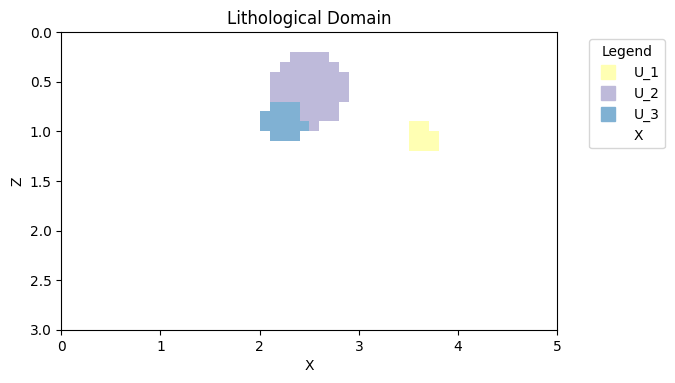

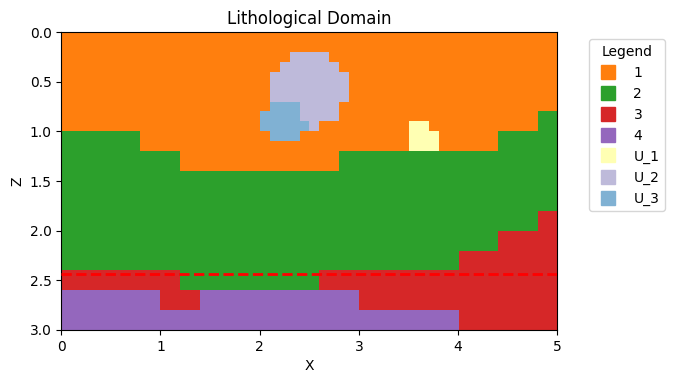

In [16]:
import matplotlib.pyplot as plt

n_obs = 3; #aux_props.aux_properties['n_obs'].generate()

obs_shapes = aux_props.aux_properties['obs_shape'].generate((n_obs,))

obs_lit = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain_final, 'obstructions')

for i, obs_shape in enumerate(obs_shapes):
    obs_x_coord = aux_props.aux_properties['obs_x_coord'].generate()
    d_obs = aux_props.aux_properties['depth_top_utils'].generate()
    obs_id = i+1
    obs_instance = obstruction2d.Obstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)
    if obs_shape == 'circ2d':
        d = aux_props.aux_properties['dia_obs'].generate()
        obs_instance.circle_2d(d, obstruction_id = obs_id)
    elif obs_shape == 'rect2d':
        lx = aux_props.aux_properties['lh_obs'].generate()
        lz = aux_props.aux_properties['lh_obs'].generate()
        obs_instance.rectangle_2d(lx, lz, obstruction_id = obs_id)
    else:
        raise ValueError(f"Invalid util_shape {obs_shape}")
    obs_instance.plot()
    obs_lit.add_obstruction2D(obs_instance, shift_ref2d_to_xy = [obs_x_coord, d_obs], added_prefix='U')

obs_lit.plot()
merged_lit = lit.return_merged_lithological_domain([obs_lit])
merged_lit.plot()


In [17]:
lit_collection = lithological_domain2d_collection.LithologicalDomain2DCollection(main_properties_config_instance.get_feature_ids(), interface_set_name="soil") 
lit_collection.add_lithological_domain_from_soil_interface_config(lit)
lit_collection.add_lithological_domain_from_obstruction2d("obs", obs_lit)
lit_collection.lock()


In [18]:
main_properties_config_instance.lock_and_generate_sample_properties(lit_collection)
main_properties_config_instance.sampled_properties

{'vs': {'1': {'both': {'mean': 459.52197687571174,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}},
  '2': {'both': {'mean': 293.21880301649924,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}},
  '3': {'both': {'mean': 173.45010847589535,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}},
  '4': {'both': {'mean': 166.02682269907947,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}},
  'U_1': {'both': {'mean': 1544.2976523581674,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}},
  'U_2': {'both': {'mean': 1349.465718029675,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}},
  'U_3': {'both': {'mean': 843.3759329690747,
    'mean_bm': 0,
    'stdev/cov': 0.05,
    'stdev_type': 'cov'}}},
 'miu': {'1': {'wet': {'mean': 0.4880520479308768,
    'mean_bm': 0,
    'stdev/cov': 0,
    'stdev_type': 'cov'},
   'dry': {'mean': 0.24115525796672221,
    'mean_bm': 0,
    'stdev/cov': 0,
    '

In [19]:
main_properties_config_instance.check_consistent_with_lit_domain2d_collection(lit_collection)

In [21]:
importlib.reload(generated_profiles)
importlib.reload(spatial_simulator2d)

#Spatial Simulator
spatial_sim = spatial_simulator2d.CovarianceDecompositionSimulator(spatial_theta_x, spatial_theta_z, rng)
# Collection

gen_profiles = generated_profiles.GeneratedProfileCollection2D(main_properties_config_instance, lit_collection, spatial_sim)
# gen_profiles.delete_simulated_property_profile('z_vals_seismic')
gen_profiles.simulate_zvals_property_profile('z_vals_seismic')
gen_profiles.simulate_property_profile('vs')        
gen_profiles.simulate_profile_from_zvals_property_profile('miu', 'z_vals_seismic')     

Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_3
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_3
Simulating z-vals for Layer ID: X


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\spatial_simulator2d.py:211: UserWarning: Extra keys in processed_property_dict ignored: {'U_1', 'U_2', 'U_3'}
  warnings.warn(f"Extra keys in processed_property_dict ignored: {extra}")
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\spatial_simulator2d.py:211: UserWarning: Extra keys in processed_property_dict ignored: {'2', '4', '3', '1'}
  warnings.warn(f"Extra keys in processed_property_dict ignored: {extra}")
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\spatial_simulator2d.py:290: UserWarning: Layer 2 (wet): sigma=0 but 7 values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\spatial_simulator2d.py:301: UserWarning: Layer 2 (dry): sigma=0 but 141 values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\spatial_simulator2d.py:290: UserWarning: Layer 4 (wet

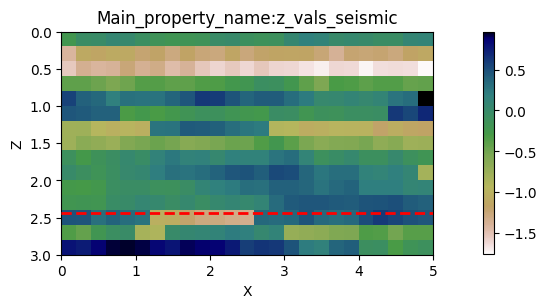

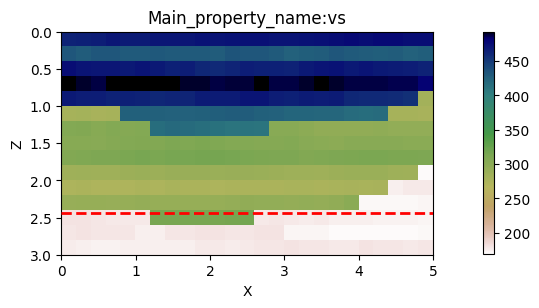

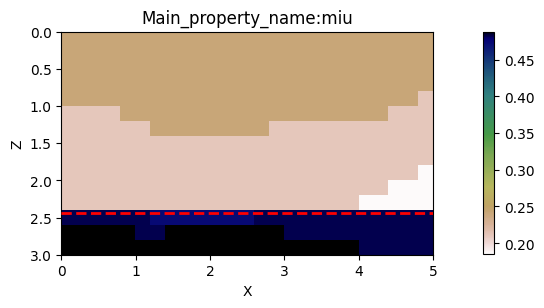

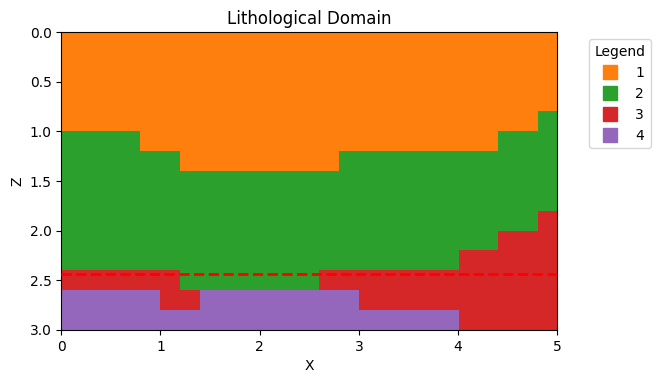

In [23]:
gen_profiles.generated_model2d_set['soil'].plot_profile('z_vals_seismic')
gen_profiles.generated_model2d_set['soil'].plot_profile('vs')
gen_profiles.generated_model2d_set['soil'].plot_profile('miu')
gen_profiles.generated_model2d_set['soil'].plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')